## Introduction to Dataset.

#### This dataset represents the Australia lighting industry, cpaturing sales data over 13 years and 10 months.It include key details such as sales dates, item type and descriptions, customer district code. Analyzing this data helps identify trends, understand market behavior, forecast future sales, and make informed business decisions. Proper data cleaning and eploration ensure accurate insights and relaiable reporting.

### Importing the dataset and libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
df=pd.read_excel("Assessment01.xlsx")
df.head()

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
0,20191025.0,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612
1,20231013.0,200.0,5.0,Landscape,3.58,Aussie Energy Group,AEG,COM,Traditional,P345
2,20241011.0,200.0,5.0,Landscape,54.5,NextGen Electrical Solutions,NES,OTH,Traditional,P345
3,20191011.0,200.0,5.0,Landscape,26,Metro Electrical Distributors,MED,OTH,Traditional,T504
4,20211021.0,400.0,5.0,Landscape,46.1,Metro Electrical Distributors,MED,COM,Traditional,T504


### Understanding the dataset

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037205 entries, 0 to 1037204
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   sales_date              951128 non-null   float64
 1   customer_district_code  951177 non-null   float64
 2   item_type               951177 non-null   float64
 3   item_type_description   1037194 non-null  object 
 4   sales                   1036784 non-null  object 
 5   business_chain_l1_name  951177 non-null   object 
 6   business_chain_l1_code  951177 non-null   object 
 7   business_area_code      951177 non-null   object 
 8   light_source            951177 non-null   object 
 9   salesperson_code        1037188 non-null  object 
dtypes: float64(3), object(7)
memory usage: 79.1+ MB


In [55]:
df.describe()

,sales_date,customer_district_code,item_type
count,9.511280e+05,951177.000000,951177.000000
mean,2.019469e+07,385.416148,5.887521
std,1.895434e+05,152.400167,1.847375
min,2.014030e+07,100.000000,1.000000
25%,2.017101e+07,300.000000,5.000000
50%,2.020101e+07,400.000000,7.000000
75%,2.022101e+07,500.000000,7.000000
max,2.027401e+08,720.000000,9.000000


In [56]:
print(df.columns)

Index(['sales_date', 'customer_district_code', 'item_type',
       'item_type_description', 'sales', 'business_chain_l1_name',
       'business_chain_l1_code', 'business_area_code', 'light_source',
       'salesperson_code'],
      dtype='object')


In [57]:
# find out missing value
df.isna().sum()

,0
sales_date,86077
customer_district_code,86028
item_type,86028
item_type_description,11
sales,421
business_chain_l1_name,86028
business_chain_l1_code,86028
business_area_code,86028
light_source,86028
salesperson_code,17


In [58]:
# Dropping rows with missing values in the sales_date column.
df_null_sales = df[df["sales_date"].isna()]
df = df.drop(df_null_sales.index)

In [59]:
df.isna().sum()

,0
sales_date,0
customer_district_code,0
item_type,0
item_type_description,10
sales,4
business_chain_l1_name,0
business_chain_l1_code,0
business_area_code,0
light_source,0
salesperson_code,17


In [60]:
# Dropping rows with missing values in the salesperson_code column.
df_null_salesperson_code = df[df["salesperson_code"].isna()]
df = df.drop(df_null_salesperson_code.index)

In [61]:
df.isna().sum()

,0
sales_date,0
customer_district_code,0
item_type,0
item_type_description,10
sales,4
business_chain_l1_name,0
business_chain_l1_code,0
business_area_code,0
light_source,0
salesperson_code,0


In [62]:
#Getting all the null values from the sale column of the dataset
df_null_saless=df[df["sales"].isna()]
df_null_saless
# Convert to integers (or numeric), invalid strings become NaN and relpacing them with the median.
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["sales"]=df["sales"].fillna(df["sales"].median())

In [63]:
df.isna().sum()

,0
sales_date,0
customer_district_code,0
item_type,0
item_type_description,10
sales,0
business_chain_l1_name,0
business_chain_l1_code,0
business_area_code,0
light_source,0
salesperson_code,0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951111 entries, 0 to 951176
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   sales_date              951111 non-null  float64
 1   customer_district_code  951111 non-null  float64
 2   item_type               951111 non-null  float64
 3   item_type_description   951101 non-null  object 
 4   sales                   951111 non-null  float64
 5   business_chain_l1_name  951111 non-null  object 
 6   business_chain_l1_code  951111 non-null  object 
 7   business_area_code      951111 non-null  object 
 8   light_source            951111 non-null  object 
 9   salesperson_code        951111 non-null  object 
dtypes: float64(4), object(6)
memory usage: 79.8+ MB


In [65]:
# coverting the sale_dates to actual dates
df["sales_date"] = df["sales_date"].astype(str)  # convert to string
df["sales_date"] = df["sales_date"].str.replace(r"\.0$", "", regex=True)  # remove .0
df["sales_date"] = pd.to_datetime(df["sales_date"], format="%Y%m%d", errors="coerce")

In [66]:
df.head()

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
0,2019-10-25,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612
1,2023-10-13,200.0,5.0,Landscape,3.58,Aussie Energy Group,AEG,COM,Traditional,P345
2,2024-10-11,200.0,5.0,Landscape,54.50,NextGen Electrical Solutions,NES,OTH,Traditional,P345
3,2019-10-11,200.0,5.0,Landscape,26.00,Metro Electrical Distributors,MED,OTH,Traditional,T504
4,2021-10-21,400.0,5.0,Landscape,46.10,Metro Electrical Distributors,MED,COM,Traditional,T504


In [67]:
df.isna().sum()

,0
sales_date,2
customer_district_code,0
item_type,0
item_type_description,10
sales,0
business_chain_l1_name,0
business_chain_l1_code,0
business_area_code,0
light_source,0
salesperson_code,0


In [68]:
# getting all the remaining null sales_date values.
null_sales_date=df[df["sales_date"].isna()]
null_sales_date
# Dropping teh remaining null sales_dates
df=df.drop(null_sales_date.index)
df.isna().sum()

,0
sales_date,0
customer_district_code,0
item_type,0
item_type_description,10
sales,0
business_chain_l1_name,0
business_chain_l1_code,0
business_area_code,0
light_source,0
salesperson_code,0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951109 entries, 0 to 951176
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   sales_date              951109 non-null  datetime64[ns]
 1   customer_district_code  951109 non-null  float64       
 2   item_type               951109 non-null  float64       
 3   item_type_description   951099 non-null  object        
 4   sales                   951109 non-null  float64       
 5   business_chain_l1_name  951109 non-null  object        
 6   business_chain_l1_code  951109 non-null  object        
 7   business_area_code      951109 non-null  object        
 8   light_source            951109 non-null  object        
 9   salesperson_code        951109 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 79.8+ MB


In [70]:
null_values=df[df["item_type_description"].isnull()]
null_values

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
16,2023-10-21,300.0,7.0,NaN,5.78,Independent Retailers Association,ZZ2,LMP,Traditional,P342
59,2022-10-19,300.0,5.0,NaN,13.10,Metro Electrical Distributors,MED,LMP,Traditional,T203
111,2022-10-09,300.0,7.0,NaN,19.90,ProLighting Specialists,ZZ3,LMP,Traditional,P347
192,2019-10-21,200.0,7.0,NaN,17.30,Builders Supply Network,ZZ1,LMP,Traditional,P415
236,2020-10-08,400.0,7.0,NaN,11.50,Builders Supply Network,ZZ1,LMP,Traditional,P248
295,2021-10-15,600.0,7.0,NaN,14.00,Builders Supply Network,ZZ1,LMP,Traditional,P237
399,2020-10-18,400.0,7.0,NaN,2.72,NextGen Electrical Solutions,NES,LMP,Traditional,P345
530,2023-10-20,200.0,7.0,NaN,17.30,Builders Supply Network,ZZ1,LMP,Traditional,P344
577,2023-10-30,200.0,5.0,NaN,129.34,NextGen Electrical Solutions,NES,COM,Traditional,T203
625,2023-10-14,310.0,5.0,NaN,65.22,NextGen Electrical Solutions,NES,COM,Traditional,P237


In [71]:
df.loc[(df['item_type'] == 7.0) & (df['item_type_description'].isna()), 'item_type_description'] = 'Decorative'

In [72]:
df.loc[(df['item_type'] == 5.0) & (df['item_type_description'].isna()), 'item_type_description'] = 'Landscape'

In [73]:
df.isna().sum()

,0
sales_date,0
customer_district_code,0
item_type,0
item_type_description,0
sales,0
business_chain_l1_name,0
business_chain_l1_code,0
business_area_code,0
light_source,0
salesperson_code,0


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951109 entries, 0 to 951176
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   sales_date              951109 non-null  datetime64[ns]
 1   customer_district_code  951109 non-null  float64       
 2   item_type               951109 non-null  float64       
 3   item_type_description   951109 non-null  object        
 4   sales                   951109 non-null  float64       
 5   business_chain_l1_name  951109 non-null  object        
 6   business_chain_l1_code  951109 non-null  object        
 7   business_area_code      951109 non-null  object        
 8   light_source            951109 non-null  object        
 9   salesperson_code        951109 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 79.8+ MB


In [75]:
for col  in df.columns:
    print(col)
    print(df[col].unique())

sales_date
<DatetimeArray>
['2019-10-25 00:00:00', '2023-10-13 00:00:00', '2024-10-11 00:00:00',
 '2019-10-11 00:00:00', '2021-10-21 00:00:00', '2021-10-28 00:00:00',
 '2021-10-06 00:00:00', '2024-10-07 00:00:00', '2022-10-10 00:00:00',
 '2021-10-26 00:00:00',
 ...
 '2014-10-22 00:00:00', '2015-10-23 00:00:00', '2028-01-05 00:00:00',
 '2028-01-02 00:00:00', '2028-01-03 00:00:00', '2027-01-03 00:00:00',
 '2027-01-05 00:00:00', '2015-10-16 00:00:00', '2018-10-27 00:00:00',
 '2020-10-31 00:00:00']
Length: 267, dtype: datetime64[ns]
customer_district_code
[400. 200. 510. 500. 310. 300. 410. 210. 600. 720. 710. 535. 530. 540.
 520. 545. 100.]
item_type
[5. 7. 6. 1. 4. 9. 8. 2. 3.]
item_type_description
['Landscape' 'Decorative' 'Healthcare' 'Wall-mount' 'Solar' 'Garage'
 'Road-and-street' 'Industrial' 'Pendants']
sales
[3.33000e+00 3.58000e+00 5.45000e+01 ... 1.95971e+04 4.27000e+02
 2.33290e+02]
business_chain_l1_name
['Metro Electrical Distributors' 'Aussie Energy Group'
 'NextGen Electri

In [76]:
df["light_source"].unique()

array(['Traditional', '"Traditional"', 'Traditionl',
       'Light Emitting Diode', 'LED', 'Accessories', 'Tradal',
       'Tradisional'], dtype=object)

In [77]:
# Define mappings for messy values
mapping = {
    '"Traditional"': "Traditional",
    'Traditionl': "Traditional",
    'Tradal': "Traditional",
    'Tradisional': "Traditional",
    'Light Emitting Diode': "LED"
}

# Replace values in 'light_source' column
df["light_source"] = df["light_source"].replace(mapping)

print(df["light_source"].unique())


['Traditional' 'LED' 'Accessories']


In [78]:
df["business_chain_l1_code"].unique()

array(['MED', 'AEG', 'NES', 'ZZ2       ', 'NLG', 'ZZ8       ', 'ELC',
       'ZZ3       ', 'BPS', 'ZZZ       ', 'INTERCO   ', 'ZZ6       ',
       'ZZ1       ', 'UES', 'GEW', 'Z3500     ', 'Z4000     ',
       'Z2000     ', 'Z4500     ', 'Z8500     ', 'Z4100     ',
       'ZZ7       ', 'ZZ5       ', 'Z6100     ', 'Z850339   ',
       'CET       ', 'PTD', 'Z6500     ', 'ZZ9       ', 'ZI900     ',
       'ZI4000    ', 'Z7500     ', 'ZI800     ', 'ZI4500    ',
       'Z3200     ', 'ZA900     ', 'ZI2000    ', 'Z850358   ',
       'Z8100     ', 'Z6800     ', 'ZI3500    ', 'ZI3000    ',
       'ZA800     ', 'Z9000     ', 'AES', 'ZA200     ', 'MES',
       'ZI80084   ', 'REP       ', 'BPD', 'UEF', 'INTERGO   ', 'nlg',
       'GEw', '"MED"'], dtype=object)

In [79]:
mapping_BCLC={'"MED"':'MED'}
# replacing the values of MED in business_chain_l1_code cloumn.
df["business_chain_l1_code"]=df["business_chain_l1_code"].replace(mapping_BCLC)
df["business_chain_l1_code"].unique()

array(['MED', 'AEG', 'NES', 'ZZ2       ', 'NLG', 'ZZ8       ', 'ELC',
       'ZZ3       ', 'BPS', 'ZZZ       ', 'INTERCO   ', 'ZZ6       ',
       'ZZ1       ', 'UES', 'GEW', 'Z3500     ', 'Z4000     ',
       'Z2000     ', 'Z4500     ', 'Z8500     ', 'Z4100     ',
       'ZZ7       ', 'ZZ5       ', 'Z6100     ', 'Z850339   ',
       'CET       ', 'PTD', 'Z6500     ', 'ZZ9       ', 'ZI900     ',
       'ZI4000    ', 'Z7500     ', 'ZI800     ', 'ZI4500    ',
       'Z3200     ', 'ZA900     ', 'ZI2000    ', 'Z850358   ',
       'Z8100     ', 'Z6800     ', 'ZI3500    ', 'ZI3000    ',
       'ZA800     ', 'Z9000     ', 'AES', 'ZA200     ', 'MES',
       'ZI80084   ', 'REP       ', 'BPD', 'UEF', 'INTERGO   ', 'nlg',
       'GEw'], dtype=object)

In [80]:
df["business_area_code"].unique()

array(['COM                           ', 'OTH                           ',
       'SUR                           ', 'LMP                           ',
       'PEN                           ', 940,
       'TRO                           ', 'DLT                           ',
       'TAL                           ', 970, 999, 980,
       'FLD                           ', 'URB                           ',
       'IAE                           ', 985,
       'LCP                           ', 'IAI                           ',
       920, 'SAE                           ',
       'EXL                           ', 'HLB                           ',
       950, 'RWY                           ', 945, 910, 960, 930],
      dtype=object)

In [81]:
df["business_area_code"]=df["business_area_code"].astype(str).str.strip()
df["business_area_code"].unique()

array(['COM', 'OTH', 'SUR', 'LMP', 'PEN', '940', 'TRO', 'DLT', 'TAL',
       '970', '999', '980', 'FLD', 'URB', 'IAE', '985', 'LCP', 'IAI',
       '920', 'SAE', 'EXL', 'HLB', '950', 'RWY', '945', '910', '960',
       '930'], dtype=object)

In [82]:
df.head()

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
0,2019-10-25,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612
1,2023-10-13,200.0,5.0,Landscape,3.58,Aussie Energy Group,AEG,COM,Traditional,P345
2,2024-10-11,200.0,5.0,Landscape,54.50,NextGen Electrical Solutions,NES,OTH,Traditional,P345
3,2019-10-11,200.0,5.0,Landscape,26.00,Metro Electrical Distributors,MED,OTH,Traditional,T504
4,2021-10-21,400.0,5.0,Landscape,46.10,Metro Electrical Distributors,MED,COM,Traditional,T504


In [83]:
# Final Check up after cleaning the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951109 entries, 0 to 951176
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   sales_date              951109 non-null  datetime64[ns]
 1   customer_district_code  951109 non-null  float64       
 2   item_type               951109 non-null  float64       
 3   item_type_description   951109 non-null  object        
 4   sales                   951109 non-null  float64       
 5   business_chain_l1_name  951109 non-null  object        
 6   business_chain_l1_code  951109 non-null  object        
 7   business_area_code      951109 non-null  object        
 8   light_source            951109 non-null  object        
 9   salesperson_code        951109 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 79.8+ MB


In [84]:
start_date=df["sales_date"].min()
end_date=df["sales_date"].max()
print(f"Start date of the dataset: {start_date}")
print(f"End date of the dataset: {end_date}")
print(f"Period covered in dataset:{end_date-start_date}")

Start date of the dataset: 2014-03-02 00:00:00
End date of the dataset: 2028-01-05 00:00:00
Period covered in dataset:5057 days 00:00:00


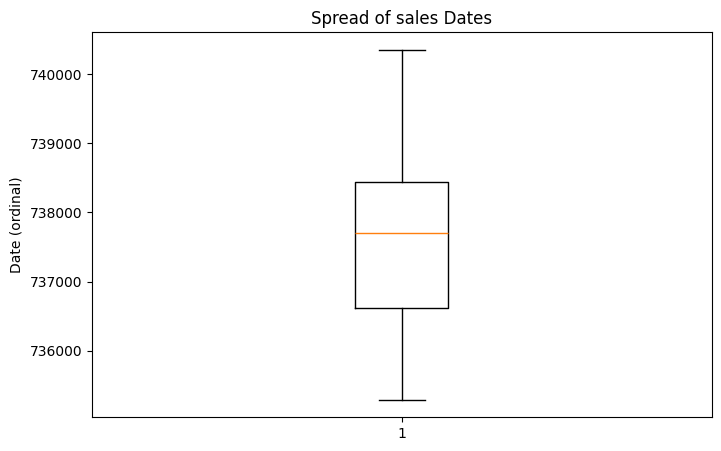

In [85]:
# understanding the spread of sales date using box plot.
plt.figure(figsize=(8,5))
plt.boxplot(df['sales_date'].map(pd.Timestamp.toordinal))
plt.title("Spread of sales Dates")
plt.ylabel("Date (ordinal)")
plt.show()

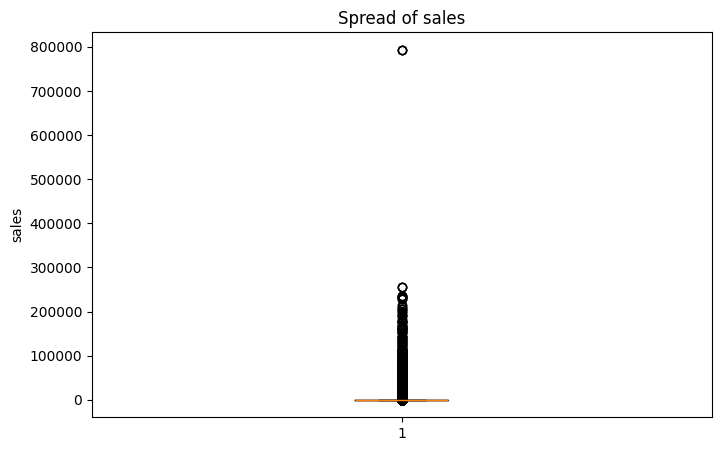

In [86]:
# Understanding the spread of sales.
plt.figure(figsize=(8,5))
plt.boxplot(df['sales'])
plt.title("Spread of sales")
plt.ylabel("sales")
plt.show()

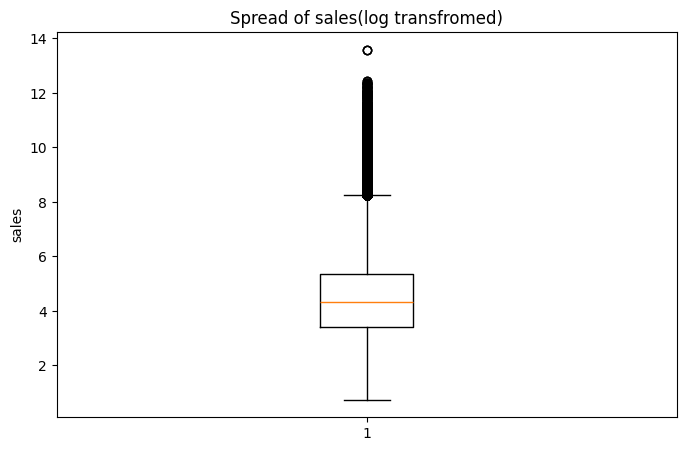

In [87]:
# Choose log transformation due to large amount of outlier in the dataset.
df["sale_log"]=np.log1p(df["sales"])
plt.figure(figsize=(8,5))
plt.boxplot(df['sale_log'])
plt.title("Spread of sales(log transfromed)")
plt.ylabel("sales")
plt.show()

In [88]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
951172,False
951173,False
951174,False
951175,False


No dupicates found in the dataset.

In [89]:
df.describe()
df.dtypes

,0
sales_date,datetime64[ns]
customer_district_code,float64
item_type,float64
item_type_description,object
sales,float64
business_chain_l1_name,object
business_chain_l1_code,object
business_area_code,object
light_source,object
salesperson_code,object


In [90]:
print(f"Shape of the data set after the EDA:{df.shape}")

Shape of the data set after the EDA:(951109, 11)


# Answer to Section 3: Analysis (10 Marks) - do not add any extra cells

## Visualisation 1 (all the codes in one cell)

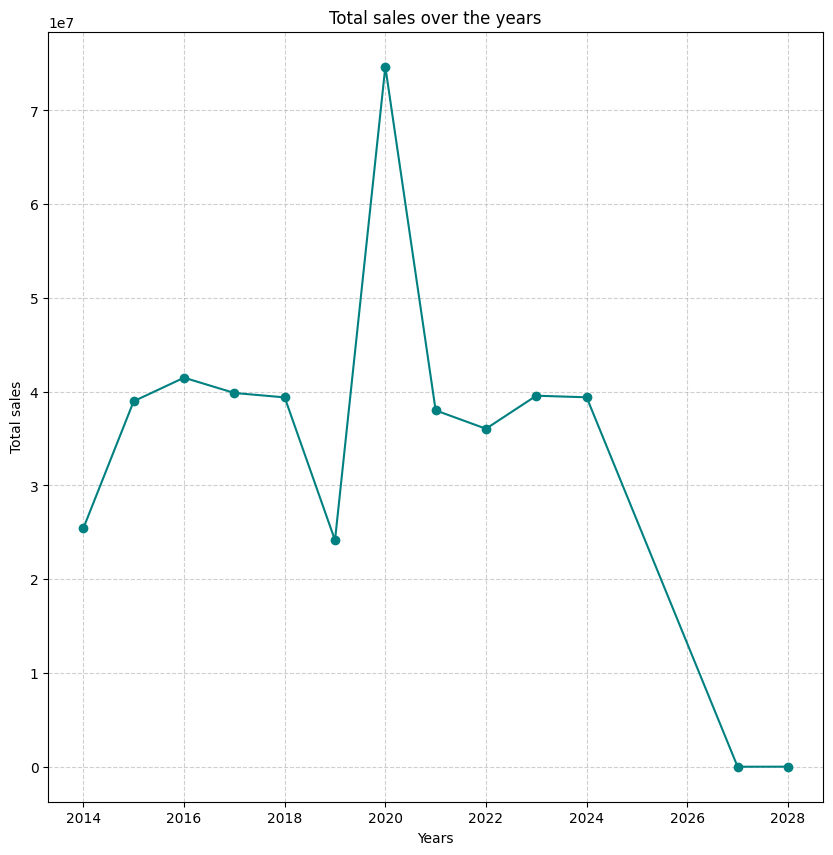

In [91]:
# Sales trends oevr the years.
df["year"]=df["sales_date"].dt.year
group_sales_year=df.groupby("year")["sales"].sum().reset_index()
plt.figure(figsize=(10,10))
plt.plot(group_sales_year["year"],group_sales_year["sales"],marker="o",linestyle="-",color="teal")
plt.title("Total sales over the years")
plt.xlabel("Years")
plt.ylabel("Total sales")
plt.grid(True,linestyle="--", alpha=0.6)
plt.show()

## Visualisation 2 (all the codes in one cell)

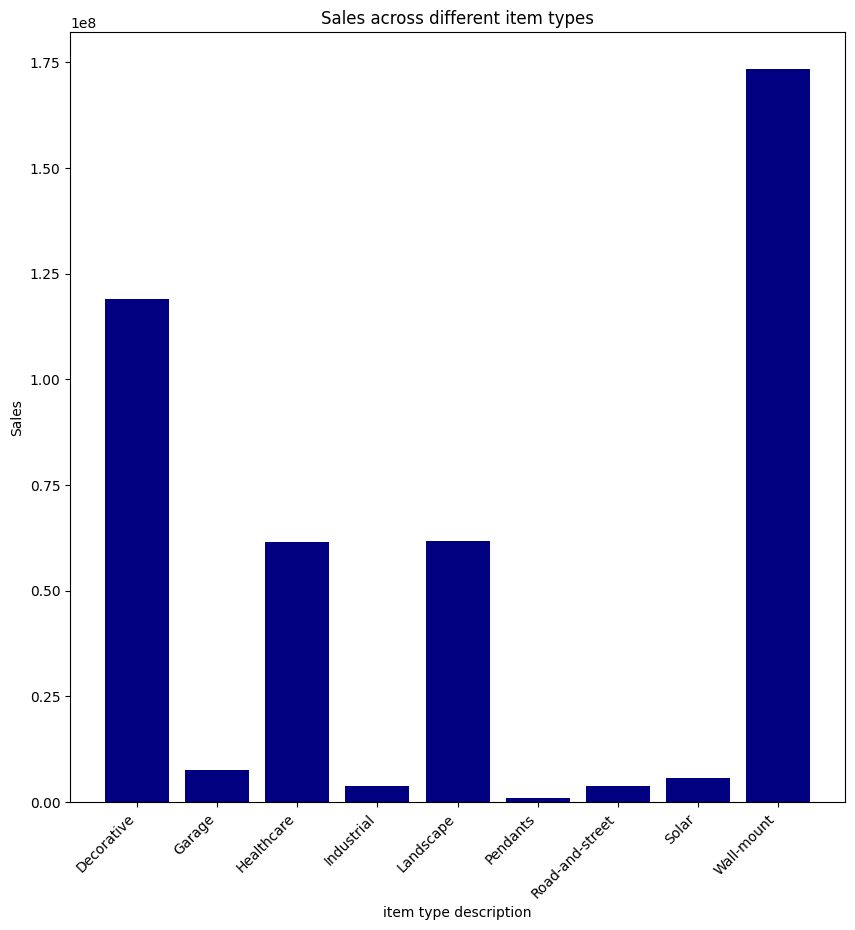

In [92]:
item_type_goups=df.groupby("item_type_description")["sales"].sum().reset_index()
plt.figure(figsize=(10,10))
plt.bar(item_type_goups["item_type_description"],item_type_goups["sales"],color="navy")
plt.title("Sales across different item types")
plt.xlabel("item type description")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Sales")
plt.show()

## Visualisation 3 (all the codes in one cell)

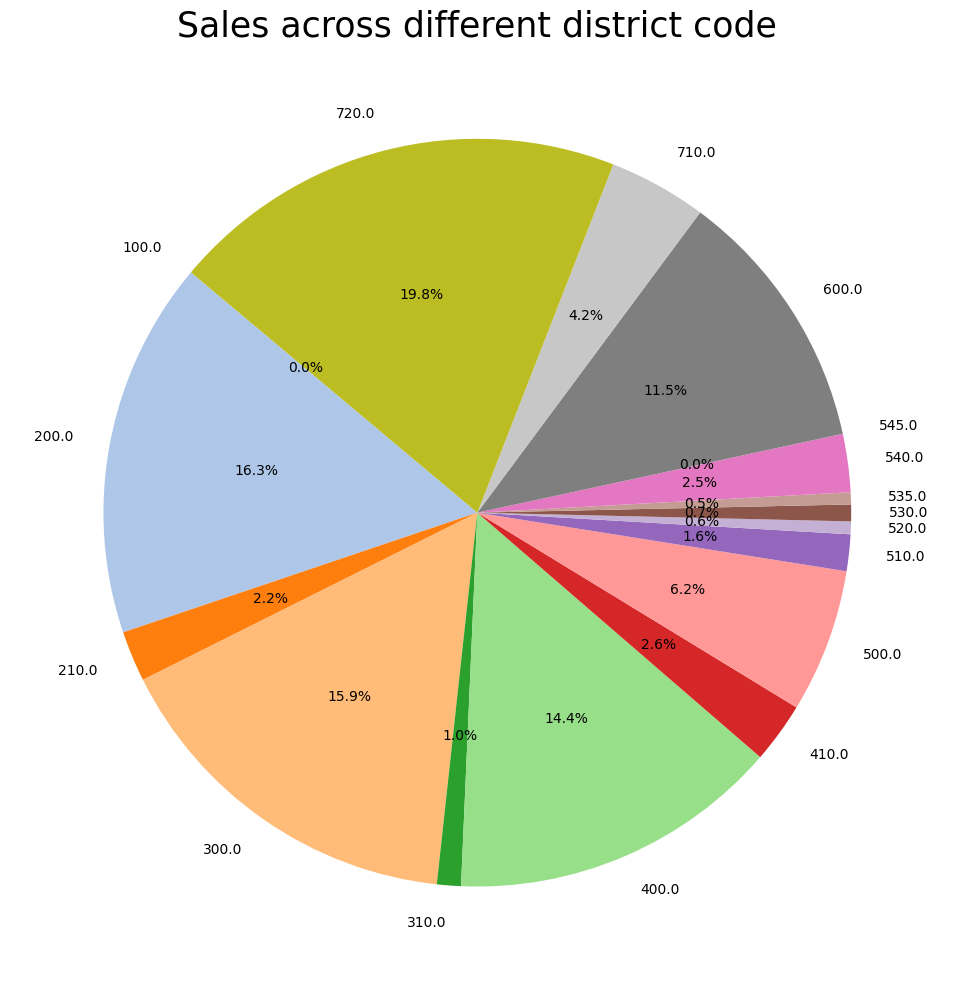

In [93]:
sales_district=df.groupby("customer_district_code")["sales"].sum().reset_index()
plt.figure(figsize=(10,10))
plt.pie(sales_district["sales"],labels=sales_district["customer_district_code"].astype(str).str.strip(),autopct="%1.1f%%",startangle=140,colors=plt.cm.tab20.colors)
plt.title("Sales across different district code",fontsize=25)
plt.tight_layout()
plt.show()

## Visualisation 4 (all the codes in one cell)

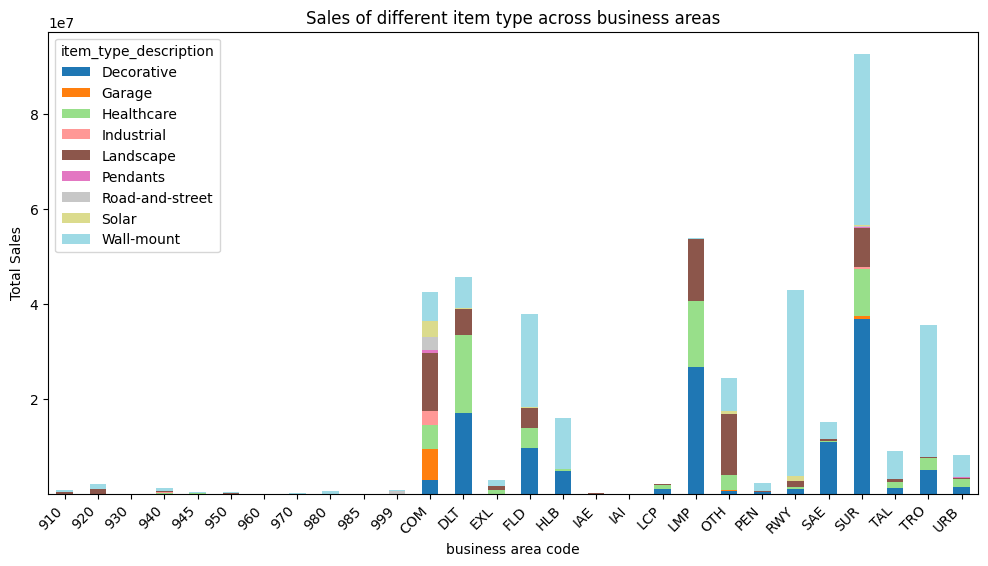

In [94]:
sales_area_item=df.groupby(["business_area_code","item_type_description"])["sales"].sum().unstack()
sales_area_item.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.xlabel("business area code")
plt.ylabel("Total Sales")
plt.title("Sales of different item type across business areas")
plt.xticks(rotation=45,ha="right")
plt.show()


## Visualisation 5 (all the codes in one cell)

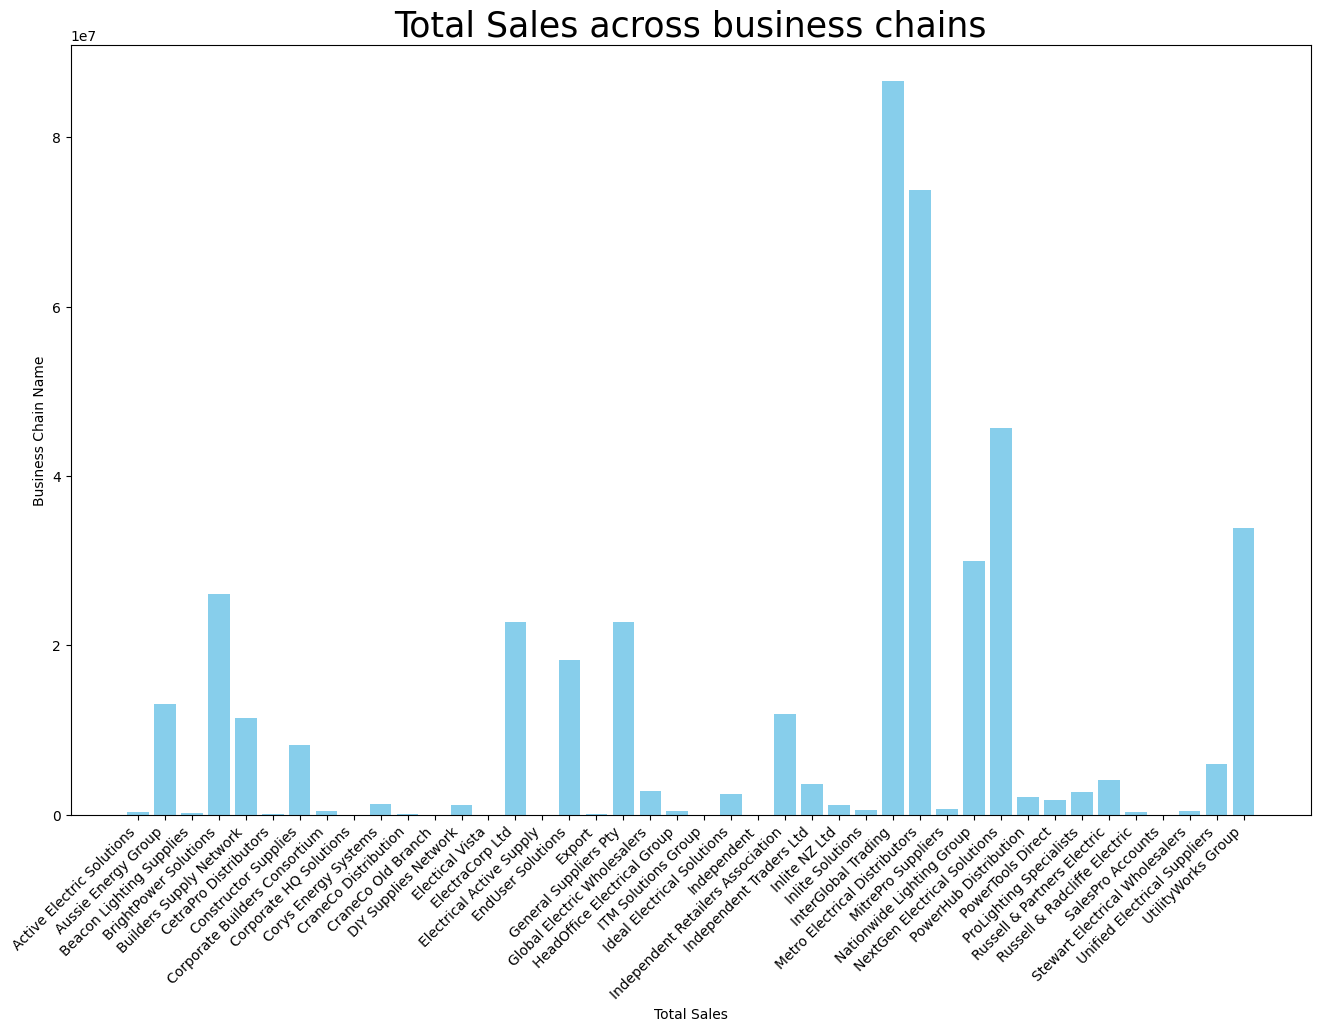

In [95]:
sales_chains=df.groupby("business_chain_l1_name")["sales"].sum().reset_index()
plt.figure(figsize=(16,10))
plt.bar(sales_chains["business_chain_l1_name"],sales_chains["sales"],color="skyblue")
plt.xticks(rotation=45,ha="right")
plt.xlabel("Total Sales")
plt.ylabel("Business Chain Name")
plt.title("Total Sales across business chains",fontsize=25)
plt.show()